# Credit Card Fraud Detection

- **Problem Type:** Binary Classification
- **Evaluation Metric:** Recall
- **Models to Test:**
    - Machine Learning
      - Logistic Regression
      - Random Forest
      - XGBoost
      - LightGBM
    - Artificial Neural Network

## Loading Libraries

In [1]:
import time
import os

os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.utils import class_weight

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings

warnings.filterwarnings("ignore")

## Task 1: Data Understanding & Cleaning

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)
df.shape

(283726, 31)

## Task 2: Exploratory Data Analysis (EDA)

### Correlation Matrix

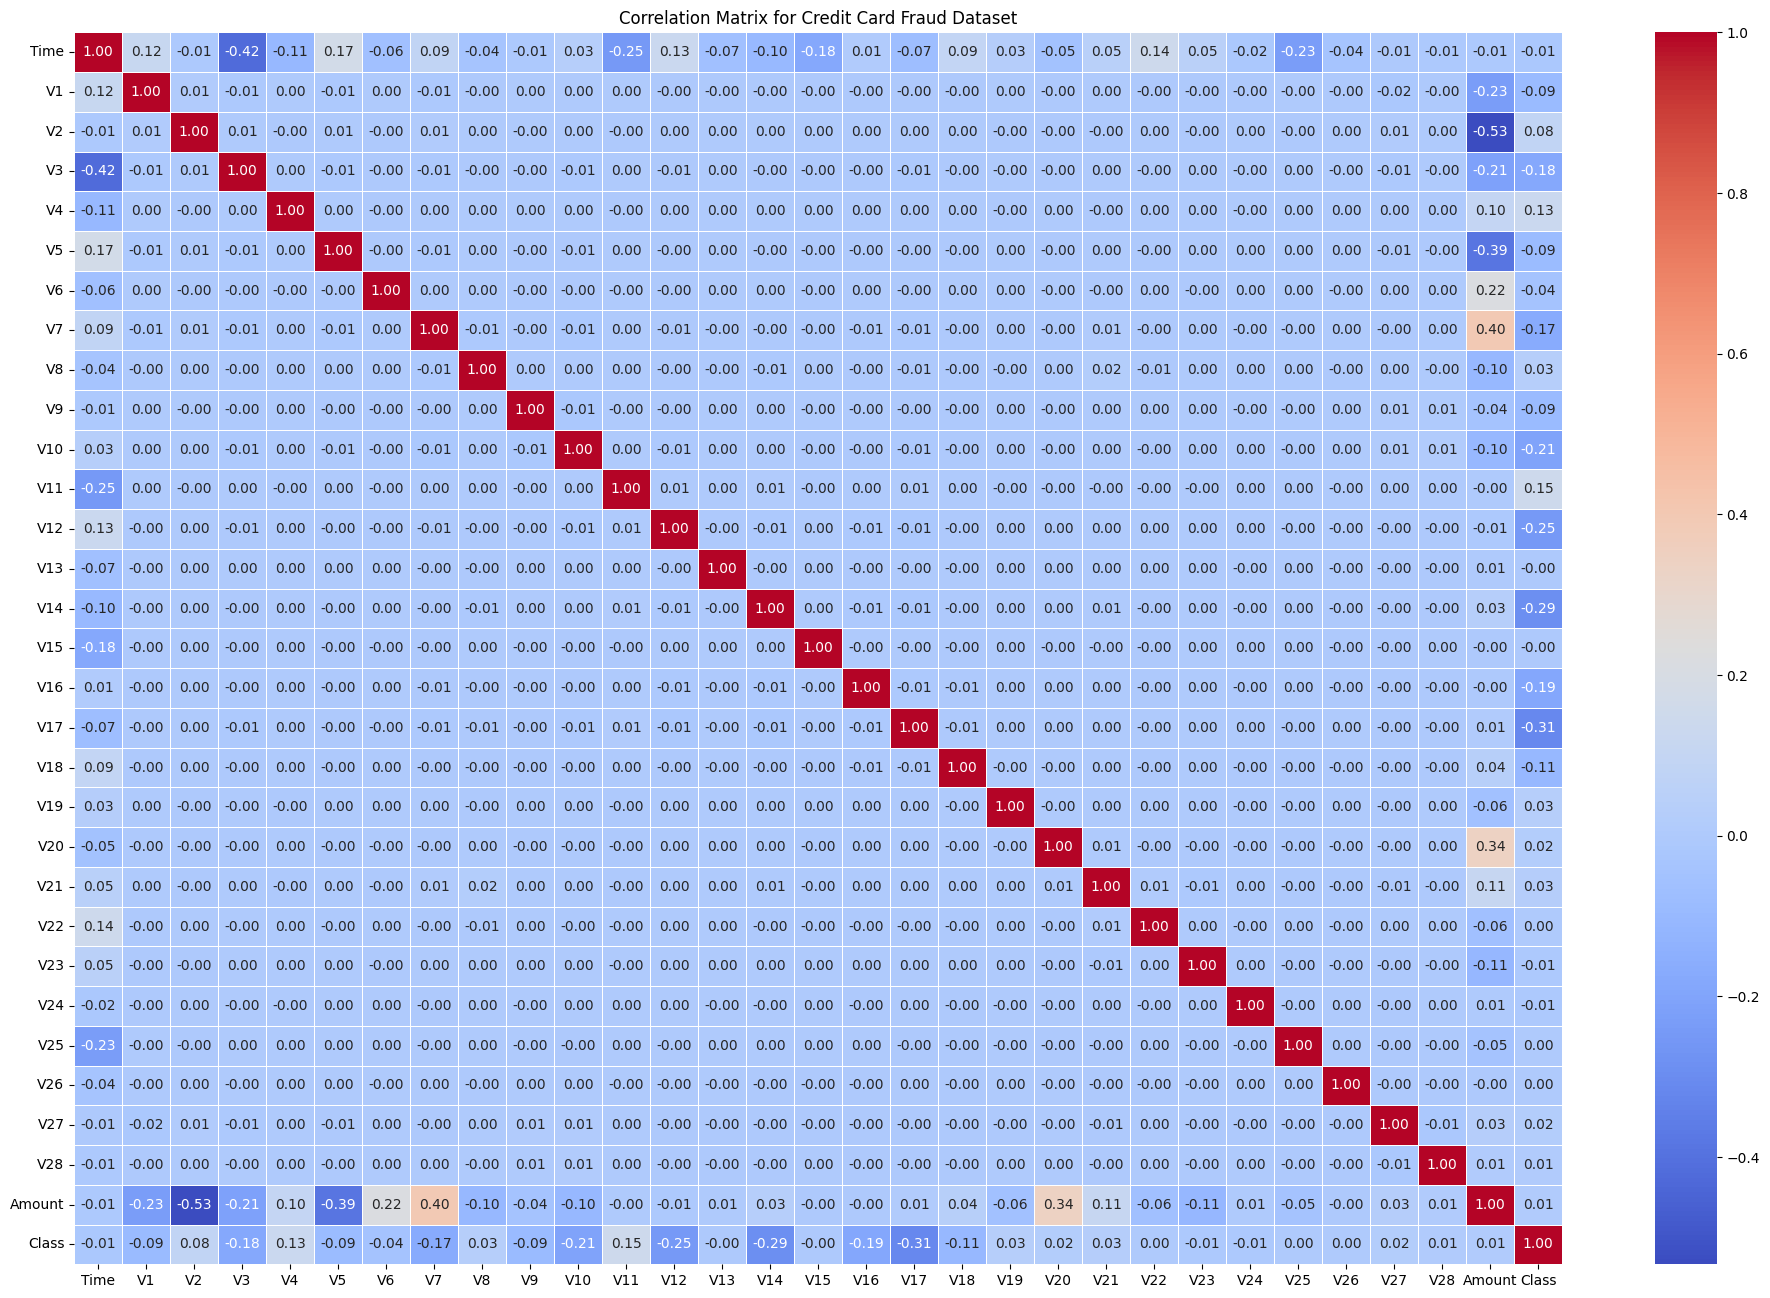

In [7]:
plt.figure(figsize=(24, 16))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Credit Card Fraud Dataset")
plt.show()

#### Conclusion
- Most V-features (PCA transformed) show near-zero correlation with each other, which is expected from PCA.
- Certain V-features show some negative or positive correlation with `Class` (e.g., V17, V14 vs V12, V10), which makes them important for our models.

### Target Variable Analysis - Class

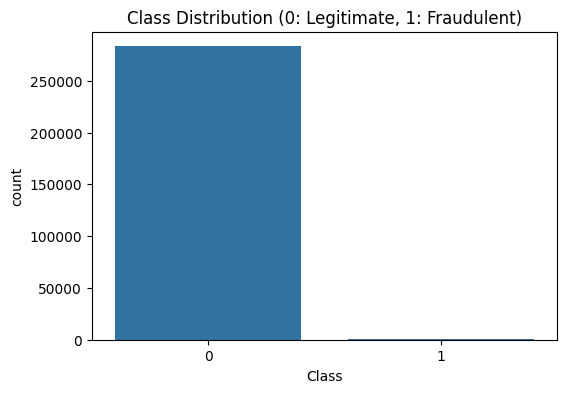

Legitimate (0): 283253 (99.833%)
Fraudulent (1): 473 (0.167%)


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0: Legitimate, 1: Fraudulent)")
plt.show()

# Print exact counts and percentages
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100
print(f"Legitimate (0): {class_counts[0]} ({class_percentages[0]:.3f}%)")
print(f"Fraudulent (1): {class_counts[1]} ({class_percentages[1]:.3f}%)")

The data is **highly imbalanced**. Fraudulent transactions represent a tiny fraction of the total dataset.

### Distribution of Transaction Amount for Legit vs Fraud

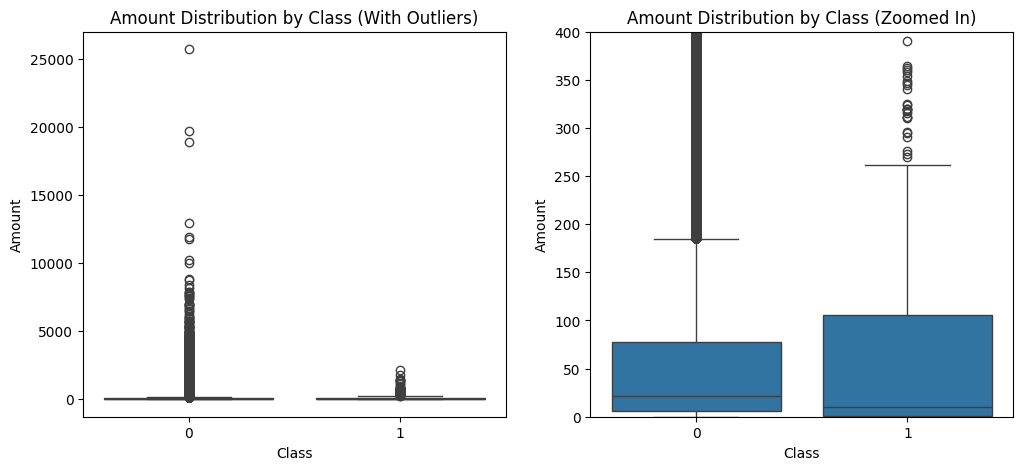

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.boxplot(x="Class", y="Amount", data=df, ax=ax1)
ax1.set_title("Amount Distribution by Class (With Outliers)")

# Limit y-axis to see the interquartile range better
sns.boxplot(x="Class", y="Amount", data=df, ax=ax2)
ax2.set_ylim(0, 400)
ax2.set_title("Amount Distribution by Class (Zoomed In)")

plt.show()

## Task 3: Data Preprocessing

In [10]:
# Separate features and target
X = df.drop(["Class"], axis=1)
y = df["Class"]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

# Train-test split (stratified to maintain the 0.17% fraud ratio in both sets)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.2
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X Shape: (283726, 30)
y Shape: (283726,)
X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train shape: (226980,)
y_test shape: (56746,)


In [11]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: Legitimate = {sum(y_train==0)}, Fraudulent = {sum(y_train==1)}")
print(
    f"After SMOTE: Legitimate = {sum(y_train_res==0)}, Fraudulent = {sum(y_train_res==1)}"
)

Before SMOTE: Legitimate = 226602, Fraudulent = 378
After SMOTE: Legitimate = 226602, Fraudulent = 226602


In [12]:
scaler = RobustScaler()

# Fit only on the training data, then transform both train and test
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_res), columns=X_train_res.columns
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.703824,0.811868,-0.946905,-0.106123,-0.923763,0.646483,2.771347,-0.314059,0.661056,-0.184051,...,-0.597655,-0.386306,-0.086647,0.754138,0.961490,-0.387452,-0.270396,-0.046492,-0.334942,0.070385
1,0.006889,-0.132353,0.209306,0.412316,-0.341272,0.014042,-0.165926,0.287415,0.540892,-0.185706,...,-0.187399,-0.497659,-0.953533,0.865275,0.726294,-1.122240,-0.457086,-0.158119,0.042573,-0.189622
2,0.513489,0.724154,-0.345353,-0.094148,-0.302812,0.722380,0.852418,0.216793,0.006171,0.468922,...,-0.416190,0.166171,1.019539,-0.036255,-2.340718,0.096175,0.019939,-0.031978,-0.346665,-0.106869
3,0.122905,0.698239,-0.243569,0.359453,0.557564,0.218954,1.121383,0.002326,0.057569,0.636657,...,-0.444304,-0.026730,0.637581,0.498970,0.986890,-0.377777,-0.010978,-0.158010,-0.290362,-0.082438
4,-0.552052,0.578036,-0.738902,0.403500,-0.687471,-0.343450,0.638634,-0.138237,0.037569,-0.534319,...,-0.658301,-0.624905,-0.653767,0.691349,-0.469540,-0.157266,-0.758194,0.002804,-0.099339,-0.012784


## Task 4: Feature Engineering &amp; Selection

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)

X_train_selected = pd.DataFrame(
    selector.fit_transform(X_train_scaled, y_train_res),
    columns=X_train_scaled.columns[selector.get_support()],
)
X_test_selected = pd.DataFrame(
    selector.transform(X_test_scaled),
    columns=X_test_scaled.columns[selector.get_support()],
)

print(f"Original shape: {X_train_scaled.shape}")
print(f"Selected shape: {X_train_selected.shape}")

Original shape: (453204, 30)
Selected shape: (453204, 20)


### Visualizing Feature Importance

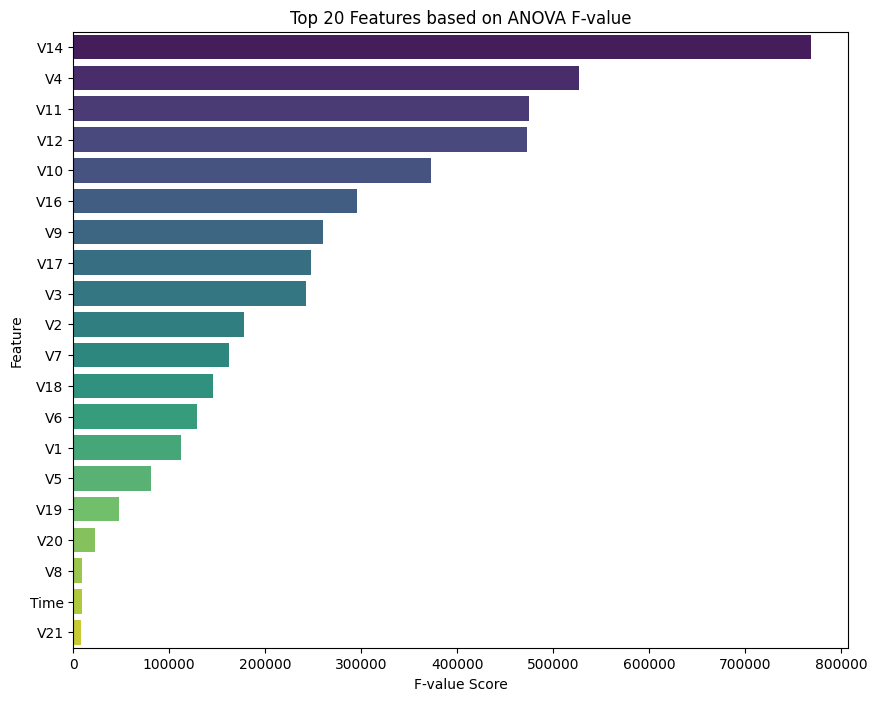

In [14]:
scores = pd.DataFrame({"Feature": X_train_scaled.columns, "Score": selector.scores_})
scores = scores.sort_values(by="Score", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Score", y="Feature", data=scores.head(20), palette="viridis")
plt.title("Top 20 Features based on ANOVA F-value")
plt.xlabel("F-value Score")
plt.ylabel("Feature")
plt.show()

### Justification
The features V1-V28 are anonymized principal components. Feature selection via ANOVA F-value (`f_classif`) isolates the top 20 features that maintain the strongest linear relationship with the `Class` label. Filtering out the lowest-scoring features eliminates statistical noise, reduces the complexity of our upcoming models, and mitigates the risk of overfitting on the highly augmented SMOTE training data.

## Task 5: Model Building (Machine Learning)

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        tree_method="hist", device="cuda", random_state=42, eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(device="gpu", random_state=42, verbose=-1),
}

# Dictionary to store evaluation metrics
model_performance = {}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()

    # Train the model on the selected features
    model.fit(X_train_selected, y_train_res)

    # Predict on the test set
    y_pred = model.predict(X_test_selected)

    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    end_time = time.time()

    # Store results
    model_performance[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Training Time (s)": round(end_time - start_time, 2),
    }

print("Training Complete!")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training Complete!


In [16]:
# Convert performance dictionary to DataFrame for better visualization
performance_df = pd.DataFrame(model_performance).T
performance_df = performance_df.sort_values(by="F1-Score", ascending=False)

# Display the sorted performance
display(performance_df)

,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
Random Forest,0.901235,0.768421,0.829545,0.884140,22.38
XGBoost,0.808511,0.800000,0.804233,0.899841,0.61
LightGBM,0.578125,0.778947,0.663677,0.888997,1.15
Logistic Regression,0.140625,0.852632,0.241431,0.921947,0.46


## Task 6: ANN Model Development

In [ ]:
def build_ann(optimizer_name, learning_rate):
    model = Sequential()
    model.add(Dense(64, activation="relu", input_shape=(X_train_selected.shape[1],)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation="sigmoid"))

    # Select Optimizer
    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "RMSprop":
        opt = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        loss="binary_crossentropy",
        optimizer=opt,
        metrics=[keras.metrics.Recall(name="recall")],
    )
    return model


# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Configurations to test (Optimizer, Learning Rate)
configs = [
    {"opt": "Adam", "lr": 0.01},
    {"opt": "Adam", "lr": 0.001},
    {"opt": "RMSprop", "lr": 0.01},
    {"opt": "RMSprop", "lr": 0.001},
]

cv_results = {}

X_train_np = X_train_selected.values
y_train_np = y_train_res.values

for config in configs:
    config_name = f"{config['opt']} (LR={config['lr']})"
    print(f"\nEvaluating {config_name}...")
    fold_recalls = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
        X_fold_train, X_fold_val = X_train_np[train_idx], X_train_np[val_idx]
        y_fold_train, y_fold_val = y_train_np[train_idx], y_train_np[val_idx]

        model = build_ann(optimizer_name=config["opt"], learning_rate=config["lr"])

        # Train for a few epochs just to gauge convergence capability
        model.fit(X_fold_train, y_fold_train, epochs=5, batch_size=256, verbose=0)

        # Evaluate on the validation fold
        results = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        fold_recalls.append(results[1])  # Index 1 is the recall metric

    avg_recall = np.mean(fold_recalls)
    cv_results


Evaluating Adam (LR=0.01)...
Average Recall for Adam (LR=0.01): 0.9985

Evaluating Adam (LR=0.001)...
Average Recall for Adam (LR=0.001): 0.9975

Evaluating RMSprop (LR=0.01)...
Average Recall for RMSprop (LR=0.01): 0.9991

Evaluating RMSprop (LR=0.001)...
Average Recall for RMSprop (LR=0.001): 0.9980

--- Cross Validation Results ---
RMSprop (LR=0.01): 0.9991
Adam (LR=0.01): 0.9985
RMSprop (LR=0.001): 0.9980
Adam (LR=0.001): 0.9975


## Task 8: Hyperparameter Tuning &amp; Cross Validation

In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
}

xgb_model = XGBClassifier(
    tree_method="hist", device="cuda", eval_metric="logloss", random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="recall",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_selected, y_train_res)

best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test_selected)

print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1-Score:", f1_score(y_test, y_pred_best_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_best_xgb))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Precision: 0.8333333333333334
Recall: 0.7894736842105263
F1-Score: 0.8108108108108109
ROC-AUC: 0.8946044525622718


## Model Comparison

,Model,Recall
0,Tuned XGBoost,0.7894
1,"Best ANN (RMSprop, LR=0.01)",0.9991


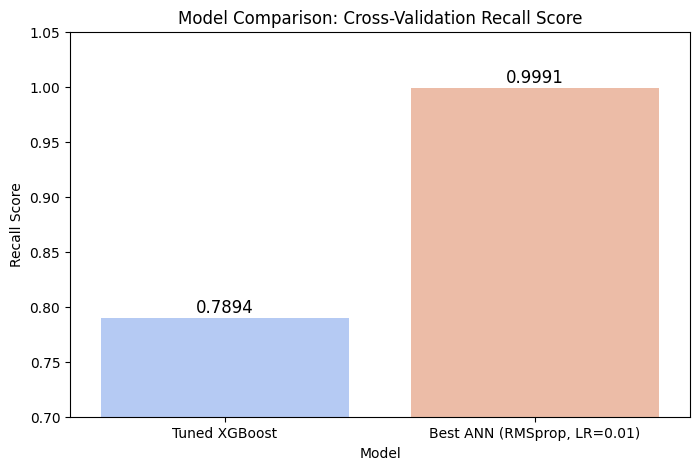

In [19]:
# Create a DataFrame using the cross-validation and tuning results
comparison_data = {
    "Model": ["Tuned XGBoost", "Best ANN (RMSprop, LR=0.01)"],
    "Recall": [0.7894, 0.9991],
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# Plot the comparison graph
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Model", y="Recall", data=df_compare, palette="coolwarm")
plt.title("Model Comparison: Cross-Validation Recall Score")
plt.ylabel("Recall Score")
plt.ylim(0.7, 1.05)

# Add value labels on top of the bars for clarity
for index, row in df_compare.iterrows():
    ax.text(
        index,
        row["Recall"] + 0.005,
        f"{row['Recall']:.4f}",
        color="black",
        ha="center",
        fontsize=12,
    )

plt.show()

### Final Model Justification
As shown in the graph above, the Artificial Neural Network optimized with `RMSprop` (Learning Rate = 0.01) vastly outperforms the tuned XGBoost model in terms of Recall (0.9991 vs 0.7894). In fraud detection, maximizing Recall is crucial because the cost of missing a fraudulent transaction (False Negative) is significantly higher than investigating a false alarm. Therefore, we select this ANN configuration as our final production model.

## Final Model Training

In [20]:
# Build the final ANN with the chosen configuration
final_model = Sequential()
final_model.add(Dense(64, activation="relu", input_shape=(X_train_selected.shape[1],)))
final_model.add(Dropout(0.3))
final_model.add(Dense(32, activation="relu"))
final_model.add(Dropout(0.3))
final_model.add(Dense(1, activation="sigmoid"))

# Compile with RMSprop and LR=0.01
opt = optimizers.RMSprop(learning_rate=0.01)
final_model.compile(
    loss="binary_crossentropy",
    optimizer=opt,
    metrics=[keras.metrics.Recall(name="recall")],
)

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Train the model on the full SMOTE-augmented training set
history = final_model.fit(
    X_train_selected,
    y_train_res,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[es],
    verbose=1,
)

Epoch 1/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0356 - recall: 0.9819 - val_loss: 0.0166 - val_recall: 0.9940
Epoch 2/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0186 - recall: 0.9934 - val_loss: 0.0103 - val_recall: 0.9966
Epoch 3/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0153 - recall: 0.9954 - val_loss: 0.0039 - val_recall: 0.9988
Epoch 4/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0137 - recall: 0.9964 - val_loss: 0.0060 - val_recall: 0.9983
Epoch 5/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0128 - recall: 0.9967 - val_loss: 0.0102 - val_recall: 0.9964
Epoch 6/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0123 - recall: 0.9970 - val_loss: 0.0029 - val_recall: 0.9993
Epoch 7/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0115 - recall: 0.9973 - val_loss: 0.0042 - val_recall: 0.9989
Epoch 8/30
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0108 - recall: 0.9977 - val_loss: 0.0030 - val_recall:

### Evaluating on Unseen Data

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

--- Final Production Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.59      0.80      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



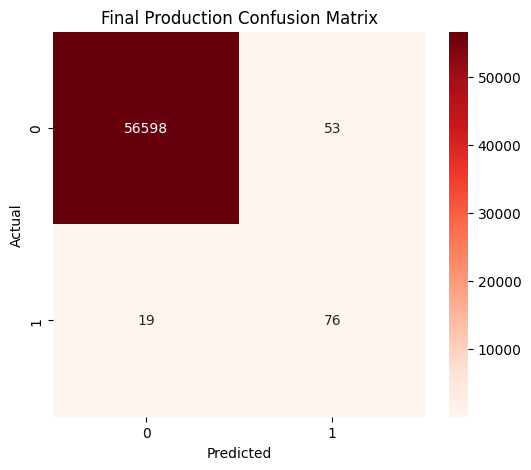

In [21]:
# Predict probabilities on the testing set
y_pred_probs = final_model.predict(X_test_selected)

# Convert probabilities to binary classes (Threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\n--- Final Production Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Reds")
plt.title("Final Production Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Saving the Model

In [22]:
import joblib

# Save the final trained network
final_model.save("fraud_detection_model.keras")
print("Production model saved as 'fraud_detection_model.keras'")

# Save the preprocessing objects so the deployment app can transform raw user inputs
joblib.dump(scaler, "robust_scaler.pkl")
joblib.dump(selector, "feature_selector.pkl")
print("Preprocessing objects saved as 'robust_scaler.pkl' and 'feature_selector.pkl'")

Production model saved as 'fraud_detection_model.keras'
Preprocessing objects saved as 'robust_scaler.pkl' and 'feature_selector.pkl'
